# 03 — Modeling, Comparison & Evaluation
**Anaemia Prediction using ML & Explainable AI**

> ⚠️ Educational decision-support prototype — **not** a diagnostic tool.

We train **two tracks** of three models each and compare them on the five required metrics:
- **Full** = all features (includes Haemoglobin) — the leaky models.
- **Hb-excluded** = the [MARKS-BOOSTER] robustness experiment.

Models are produced by `python -m src.train`; metrics by `src/evaluate.py`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src import config
from src.evaluate import evaluate_all, best_model, PRETTY
print('Setup OK')

Setup OK


## 1. Evaluate every model (both tracks)
`evaluate_all()` loads the six saved models, scores them on the held-out test set, writes `reports/metrics.json`, and saves ROC + confusion-matrix figures.

In [2]:
results = evaluate_all(save=True)
full = pd.DataFrame(results['full']).T[['accuracy','precision','recall','f1','roc_auc']].round(3)
nohb = pd.DataFrame(results['nohb']).T[['accuracy','precision','recall','f1','roc_auc']].round(3)
print('FULL track (with Haemoglobin):'); display(full)
print('Hb-EXCLUDED track:'); display(nohb)

FULL track (with Haemoglobin):


,accuracy,precision,recall,f1,roc_auc
random_forest,1.000,1.000,1.0,1.000,1.000
svm,0.963,0.925,1.0,0.961,0.999
xgboost,1.000,1.000,1.0,1.000,1.000


Hb-EXCLUDED track:


,accuracy,precision,recall,f1,roc_auc
random_forest,0.542,0.500,0.531,0.515,0.505
svm,0.626,0.585,0.633,0.608,0.628
xgboost,0.486,0.442,0.469,0.455,0.480


## 2. The five metrics, per model (full track)
All three near-perfect — expected, because the label IS a haemoglobin rule.

In [3]:
print('Best full-track model by F1:', best_model(results,'full'))
full

Best full-track model by F1: random_forest


,accuracy,precision,recall,f1,roc_auc
random_forest,1.000,1.000,1.0,1.000,1.000
svm,0.963,0.925,1.0,0.961,0.999
xgboost,1.000,1.000,1.0,1.000,1.000


## 3. ROC curves & confusion matrices (full track)
ROC-AUC ~1.0 and clean confusion matrices confirm near-perfect separation.

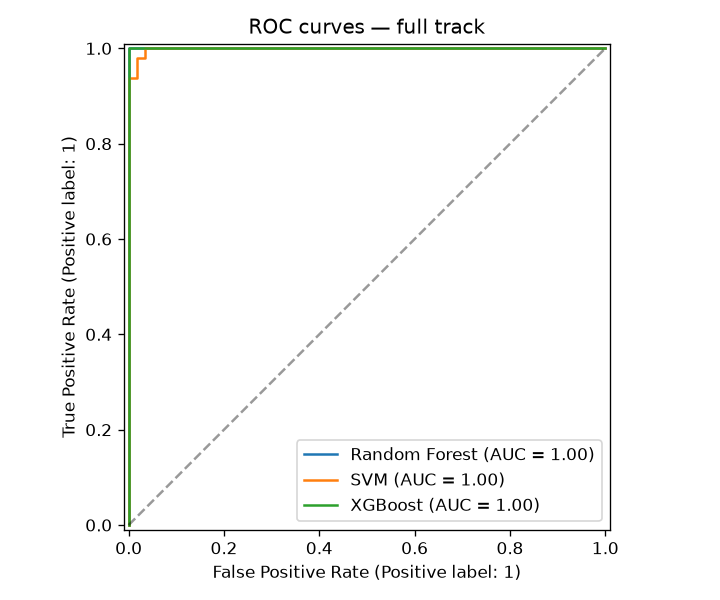

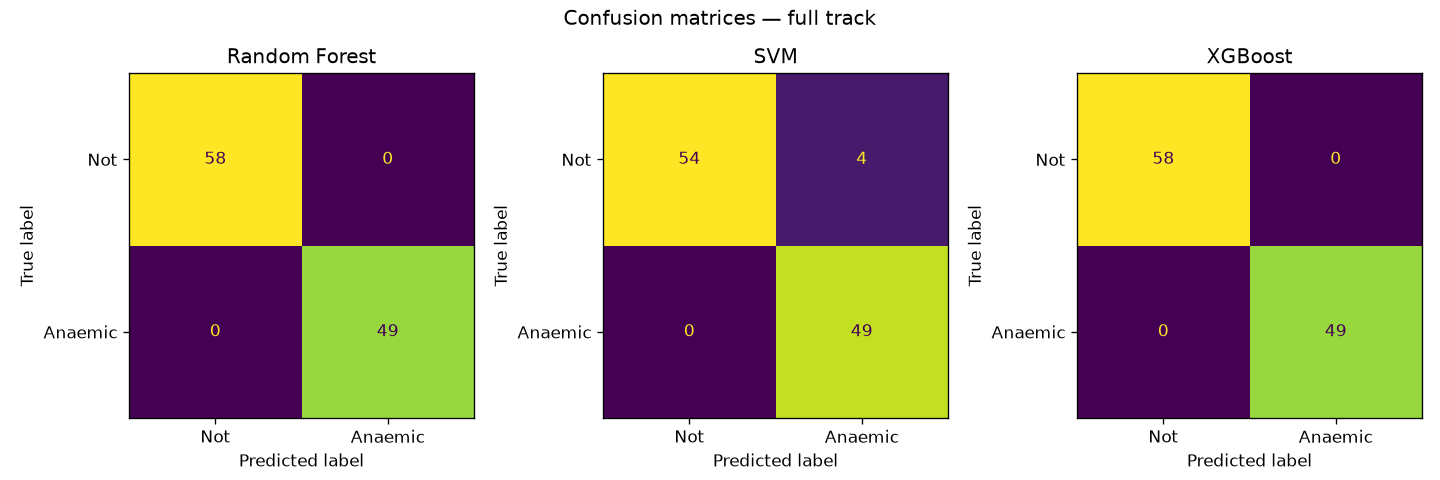

In [4]:
display(Image(str(config.FIGURES_DIR/'fig_roc_full.png')))
display(Image(str(config.FIGURES_DIR/'fig_confusion_full.png')))

## 4. 🚩 The leakage made quantitative — full vs Hb-excluded
Remove Haemoglobin and performance collapses toward **chance (0.5)** — proving the label carries essentially no signal beyond Hb.

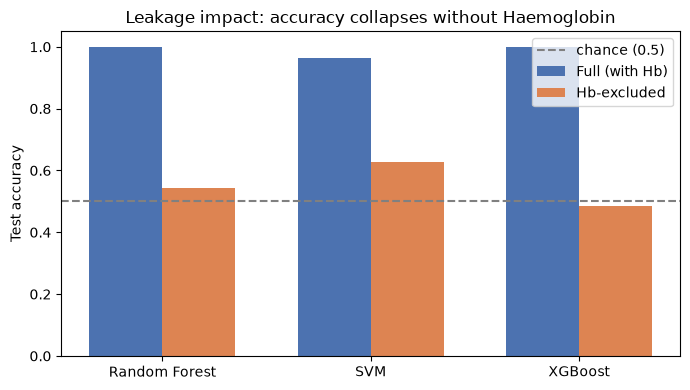

In [5]:
models = config.MODEL_NAMES
x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, [results['full'][m]['accuracy'] for m in models], w, label='Full (with Hb)', color='#4c72b0')
ax.bar(x+w/2, [results['nohb'][m]['accuracy'] for m in models], w, label='Hb-excluded', color='#dd8452')
ax.axhline(0.5, ls='--', color='grey', label='chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels([PRETTY[m] for m in models])
ax.set_ylabel('Test accuracy'); ax.set_ylim(0,1.05)
ax.set_title('Leakage impact: accuracy collapses without Haemoglobin')
ax.legend()
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fig_metrics_comparison.png', dpi=120); plt.show()

## 5. Hb-excluded ROC & confusion (the honest picture)

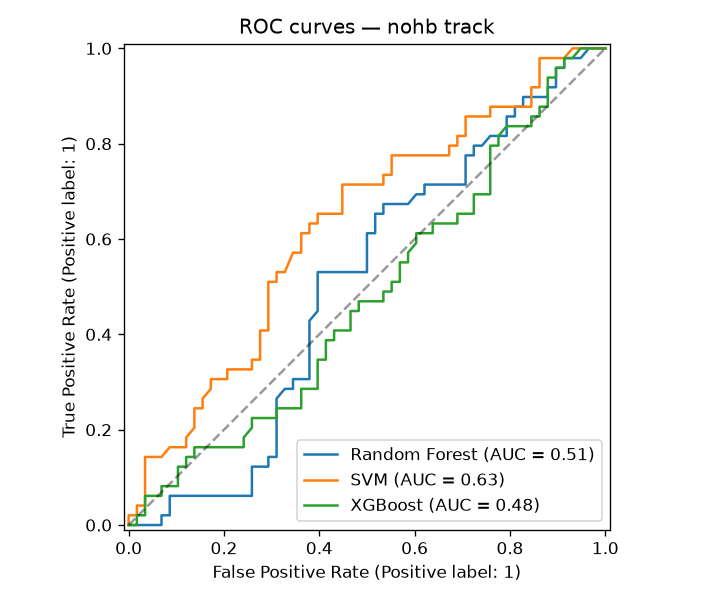

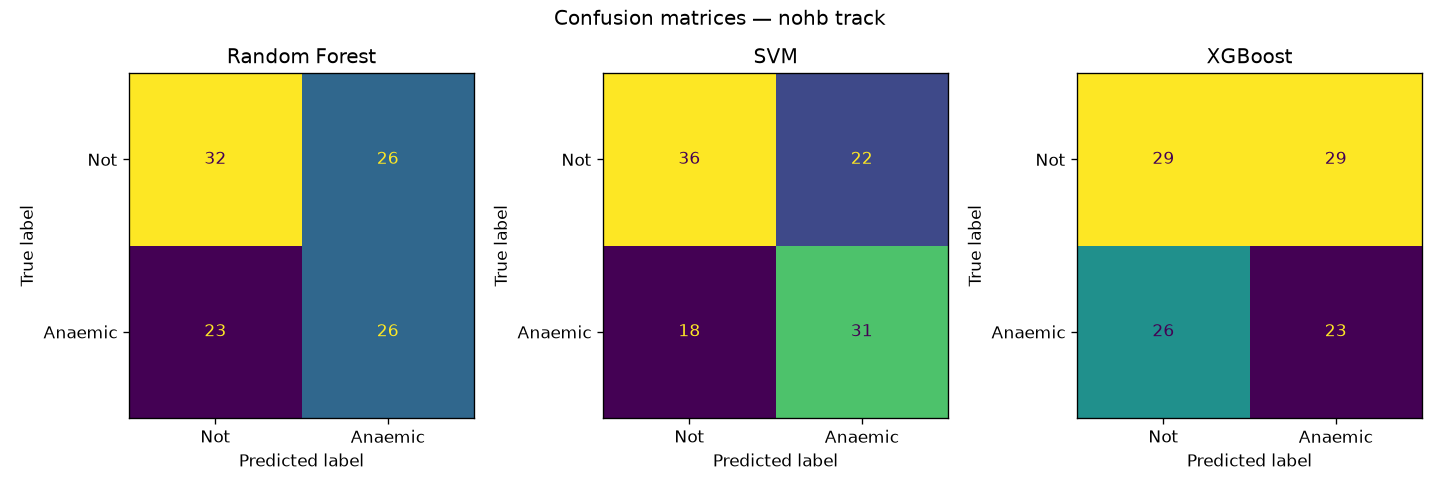

In [6]:
display(Image(str(config.FIGURES_DIR/'fig_roc_nohb.png')))
display(Image(str(config.FIGURES_DIR/'fig_confusion_nohb.png')))

## 6. Findings
- **Full track:** RF & XGBoost reach 100% on all five metrics; SVM ~0.96. This is **expected leakage**, not skill — the label is a gender-specific Hb threshold.
- **Hb-excluded track:** accuracy/AUC fall to **~0.5–0.63 (near chance)** -> the other CBC indices carry almost no signal for THIS label.
- **Overfitting visible:** Hb-excluded trees score train~0.92 but test~0.49 — they memorise noise when no real signal exists; SVM (regularised) stays near chance on both.
- **Conclusion:** the project's contribution is the **honest comparison + explainability pipeline** that *detected and quantified* the leakage — not the headline accuracy.
- Metrics saved to `reports/metrics.json`. Next: **Phase 6 — SHAP + LIME explainability.**